In [ ]:
## LOAD DATA DIRECTLY FROM GITHUB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

penguins = pd.read_csv(url)

print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  


In [2]:
# EXPLORE DATA
print(penguins.shape)
print(penguins.columns)
print(penguins.info())
print(penguins.describe())

(344, 8)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386 

In [3]:
# CHECK MISSING VALUES
print(penguins.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [6]:
# DROP MISSING ROWS
penguins_clean = penguins.dropna()

print(penguins_clean.shape)

(333, 8)


In [7]:
# COUNT PENGUINS BY SPECIES
species_counts = penguins_clean["species"].value_counts()

print(species_counts)

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


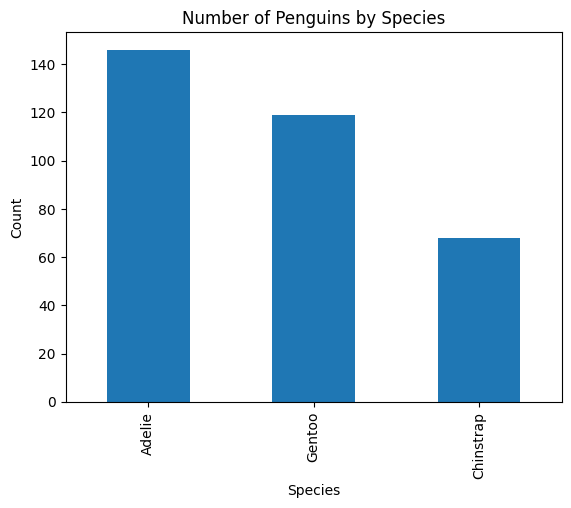

In [9]:
# PLOT PENGUINGS BY SPECIES
species_counts.plot(kind="bar")

plt.title("Number of Penguins by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [10]:
# AVERAGE BODY MASS BY SPECIES
body_mass_by_species = penguins_clean.groupby("species")["body_mass_g"].mean()

print(body_mass_by_species)

species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64


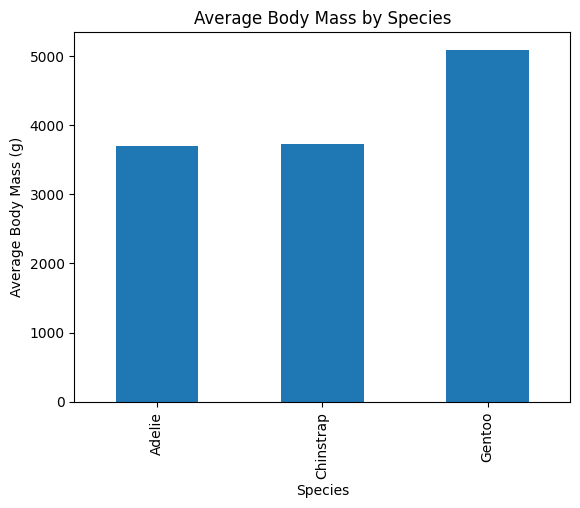

In [11]:
# PLOT AVERAGE BODY MASS BY SPECIES
body_mass_by_species.plot(kind="bar")

plt.title("Average Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Average Body Mass (g)")
plt.show()

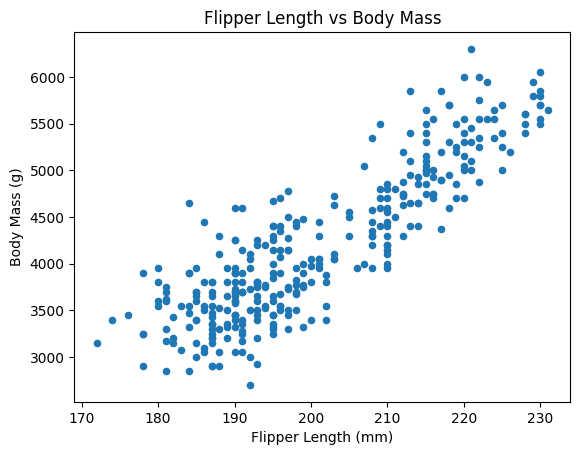

In [13]:
# SCATTER PLOT: FLIPPER LENGTH VS BODY MASS

# Do penguins with longer flippers tend to have higher body mass?

penguins_clean.plot(
    x="flipper_length_mm",
    y="body_mass_g",
    kind="scatter"
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

In [14]:
## GROUP BY TWO COLUMNS
summary = penguins_clean.groupby(["species", "island"])["body_mass_g"].mean()

print(summary)

species    island   
Adelie     Biscoe       3709.659091
           Dream        3701.363636
           Torgersen    3708.510638
Chinstrap  Dream        3733.088235
Gentoo     Biscoe       5092.436975
Name: body_mass_g, dtype: float64


In [15]:
summary_table = penguins_clean.pivot_table(
    values="body_mass_g",
    index="species",
    columns="island",
    aggfunc="mean"
)

print(summary_table)

island          Biscoe        Dream    Torgersen
species                                         
Adelie     3709.659091  3701.363636  3708.510638
Chinstrap          NaN  3733.088235          NaN
Gentoo     5092.436975          NaN          NaN
